# Real Data 01 - Setup and Calibration

This notebook starts the real-data stage of the project.

## Objective

Use historical equity data to estimate the inputs needed for the same basket-option framework used in the synthetic study:

- annualized volatilities;
- constant-correlation matrix;
- calm/stress correlation matrices;
- empirical regime-transition probabilities.

We are **not** pricing a traded basket option quote yet. We are calibrating a real-data-informed model for **hypothetical** basket options.

## Basket choice

We use a semiconductor basket because the names share a strong industry factor and should give a clearer dependence structure than a mixed-sector basket.

In [1]:
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


PROJECT_ROOT = find_project_root()
REAL_DIR = PROJECT_ROOT / "real_simulation"
DATA_DIR = REAL_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
tickers = ["NVDA", "AVGO", "MU", "AMAT", "LRCX"]
start_date = "2018-01-01"
end_date = "2026-03-13"
rolling_vol_window = 21
stress_quantile = 0.85
trading_days_per_year = 252

config = pd.Series(
    {
        "start_date": start_date,
        "end_date": end_date,
        "rolling_vol_window_days": rolling_vol_window,
        "stress_quantile": stress_quantile,
        "n_tickers": len(tickers),
    },
    name="value",
)

display(Markdown("## Configuration"))
display(config.to_frame())
display(Markdown("**Selected semiconductor basket**"))
display(pd.DataFrame({"ticker": tickers}))

## Configuration

,value
start_date,2018-01-01
end_date,2026-03-13
rolling_vol_window_days,21
stress_quantile,0.8500
n_tickers,5


**Selected semiconductor basket**

,ticker
0,NVDA
1,AVGO
2,MU
3,AMAT
4,LRCX


In [3]:
def fetch_stooq_close(ticker: str) -> pd.DataFrame:
    url = f"https://stooq.com/q/d/l/?s={ticker.lower()}.us&i=d"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    frame = pd.read_csv(StringIO(response.text))
    frame["Date"] = pd.to_datetime(frame["Date"])
    frame = frame.sort_values("Date").reset_index(drop=True)
    frame = frame.rename(columns={"Close": ticker})
    return frame[["Date", ticker]]


def estimate_transition_probabilities(states: pd.Series) -> tuple[float, float]:
    previous = states.iloc[:-1].to_numpy()
    current = states.iloc[1:].to_numpy()

    n00 = np.sum((previous == 0) & (current == 0))
    n01 = np.sum((previous == 0) & (current == 1))
    n10 = np.sum((previous == 1) & (current == 0))
    n11 = np.sum((previous == 1) & (current == 1))

    p01 = n01 / (n00 + n01) if (n00 + n01) > 0 else np.nan
    p10 = n10 / (n10 + n11) if (n10 + n11) > 0 else np.nan
    return p01, p10

In [4]:
close_frames = []
for ticker in tickers:
    frame = fetch_stooq_close(ticker)
    close_frames.append(frame)

prices = close_frames[0]
for frame in close_frames[1:]:
    prices = prices.merge(frame, on="Date", how="outer")

prices = prices.sort_values("Date").set_index("Date")
prices = prices.loc[start_date:end_date].dropna()

if prices.empty:
    raise ValueError("The downloaded price panel is empty after date filtering and NA removal.")

prices.to_csv(DATA_DIR / "semiconductor_prices.csv")
pd.DataFrame({"ticker": tickers}).to_csv(DATA_DIR / "selected_tickers.csv", index=False)

basket_weights = np.full(len(tickers), 1.0 / len(tickers))
normalized_prices = prices / prices.iloc[0]

display(Markdown("## Downloaded price panel"))
display(prices.head())
display(prices.tail())
display(
    Markdown(
        f"Price sample covers **{prices.index.min().date()}** through **{prices.index.max().date()}** with **{len(prices)}** aligned trading days."
    )
)

## Downloaded price panel

,NVDA,AVGO,MU,AMAT,LRCX
Date,,,,,
2018-01-02,4.9298,21.6795,43.3276,49.7589,17.0983
2018-01-03,5.2544,21.9183,44.6262,50.6395,17.3903
2018-01-04,5.2823,21.9240,46.5116,50.9302,17.4688
2018-01-05,5.3273,22.0531,45.4399,51.2221,17.7434
2018-01-08,5.4897,22.1079,45.1919,52.4599,17.8763


,NVDA,AVGO,MU,AMAT,LRCX
Date,,,,,
2026-03-09,182.6400,345.7500,389.4550,339.0200,211.2200
2026-03-10,184.7600,342.5200,403.4400,345.8800,215.2000
2026-03-11,186.0300,341.5700,418.6900,351.0700,218.8700
2026-03-12,183.1400,335.9700,405.3500,337.2700,209.4900
2026-03-13,180.2500,322.1600,426.1300,341.5300,212.2000


Price sample covers **2018-01-02** through **2026-03-13** with **2060** aligned trading days.

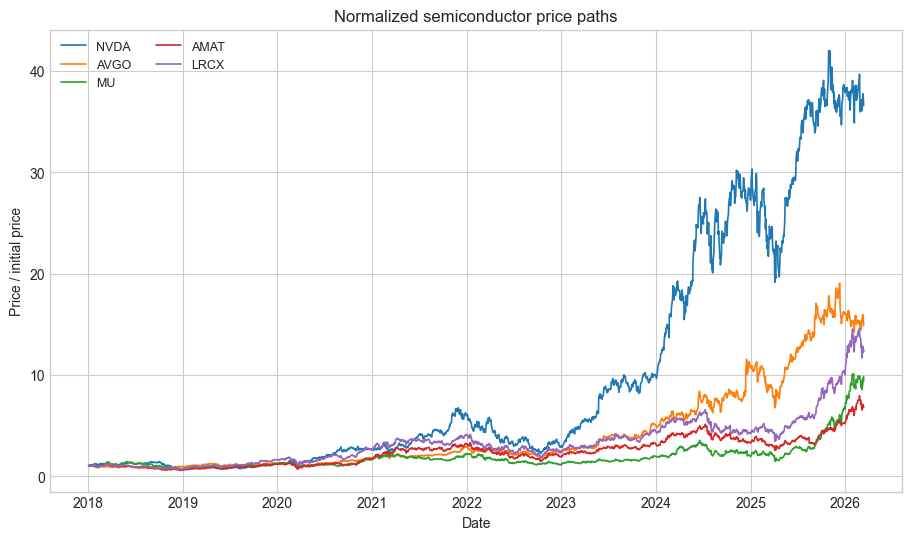

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
for ticker in tickers:
    ax.plot(normalized_prices.index, normalized_prices[ticker], linewidth=1.2, label=ticker)

ax.set_title("Normalized semiconductor price paths")
ax.set_ylabel("Price / initial price")
ax.set_xlabel("Date")
ax.legend(ncol=2, fontsize=9)
plt.show()

In [6]:
log_returns = np.log(prices / prices.shift(1)).dropna()
annualized_vols = log_returns.std() * np.sqrt(trading_days_per_year)
constant_corr = log_returns.corr()

vol_table = (
    annualized_vols.rename("annualized_volatility")
    .to_frame()
    .reset_index()
    .rename(columns={"index": "ticker"})
    .sort_values("annualized_volatility", ascending=False)
)

log_returns.to_csv(DATA_DIR / "semiconductor_log_returns.csv")
vol_table.to_csv(DATA_DIR / "annualized_volatility_estimates.csv", index=False)
constant_corr.to_csv(DATA_DIR / "constant_correlation_matrix.csv")

display(Markdown("## Annualized volatility estimates"))
display(vol_table)

display(Markdown("## Constant-correlation matrix"))
display(constant_corr.round(4))

## Annualized volatility estimates

,ticker,annualized_volatility
0,NVDA,0.5093
2,MU,0.4997
4,LRCX,0.4685
3,AMAT,0.4504
1,AVGO,0.4126


## Constant-correlation matrix

,NVDA,AVGO,MU,AMAT,LRCX
NVDA,1.0000,0.6433,0.6104,0.6735,0.6643
AVGO,0.6433,1.0000,0.6162,0.6693,0.6692
MU,0.6104,0.6162,1.0000,0.7205,0.7560
AMAT,0.6735,0.6693,0.7205,1.0000,0.9127
LRCX,0.6643,0.6692,0.7560,0.9127,1.0000


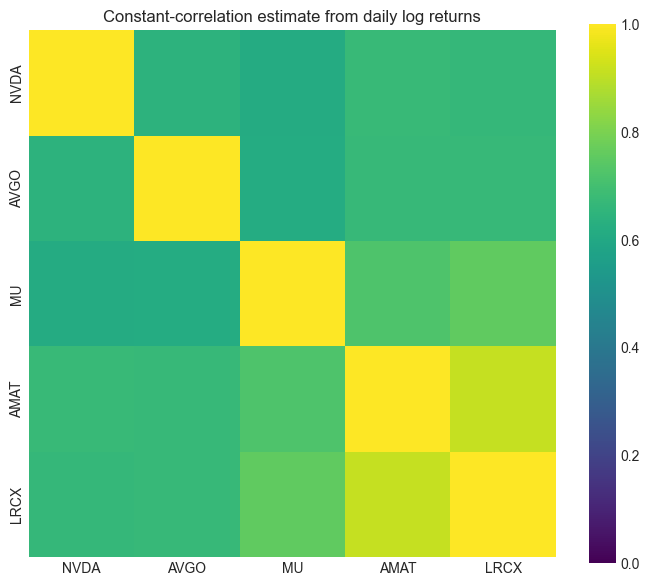

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(constant_corr, cmap="viridis", vmin=0, vmax=1, square=True, ax=ax)
ax.set_title("Constant-correlation estimate from daily log returns")
plt.show()

In [8]:
basket_log_return = log_returns.mean(axis=1)
rolling_realized_vol = basket_log_return.rolling(rolling_vol_window).std() * np.sqrt(trading_days_per_year)
stress_threshold = rolling_realized_vol.quantile(stress_quantile)

regime_labels = pd.DataFrame(
    {
        "basket_log_return": basket_log_return,
        "rolling_realized_vol": rolling_realized_vol,
    }
).dropna()
regime_labels["regime"] = (regime_labels["rolling_realized_vol"] >= stress_threshold).astype(int)
regime_labels["regime_label"] = regime_labels["regime"].map({0: "calm", 1: "stress"})

stress_share = float(regime_labels["regime"].mean())
p01, p10 = estimate_transition_probabilities(regime_labels["regime"])

calm_returns = log_returns.loc[regime_labels.index[regime_labels["regime"] == 0]]
stress_returns = log_returns.loc[regime_labels.index[regime_labels["regime"] == 1]]

calm_corr = calm_returns.corr()
stress_corr = stress_returns.corr()

regime_labels.to_csv(DATA_DIR / "regime_labels.csv")
calm_corr.to_csv(DATA_DIR / "calm_correlation_matrix.csv")
stress_corr.to_csv(DATA_DIR / "stress_correlation_matrix.csv")

transition_matrix = pd.DataFrame(
    [[1.0 - p01, p01], [p10, 1.0 - p10]],
    index=["calm", "stress"],
    columns=["to_calm", "to_stress"],
)
transition_matrix.to_csv(DATA_DIR / "regime_transition_matrix.csv")

calibration_summary = pd.DataFrame(
    [
        {"parameter": "stress_threshold", "value": float(stress_threshold)},
        {"parameter": "stress_share", "value": stress_share},
        {"parameter": "p01", "value": float(p01)},
        {"parameter": "p10", "value": float(p10)},
        {"parameter": "n_calm_days", "value": int((regime_labels["regime"] == 0).sum())},
        {"parameter": "n_stress_days", "value": int((regime_labels["regime"] == 1).sum())},
    ]
)
calibration_summary.to_csv(DATA_DIR / "calibration_summary.csv", index=False)

display(Markdown("## Regime classification summary"))
display(calibration_summary)
display(Markdown("## Estimated transition matrix"))
display(transition_matrix)

## Regime classification summary

,parameter,value
0,stress_threshold,0.4877
1,stress_share,0.1501
2,p01,0.0173
3,p10,0.0980
4,n_calm_days,"1,733.0000"
5,n_stress_days,306.0000


## Estimated transition matrix

,to_calm,to_stress
calm,0.9827,0.0173
stress,0.0980,0.9020


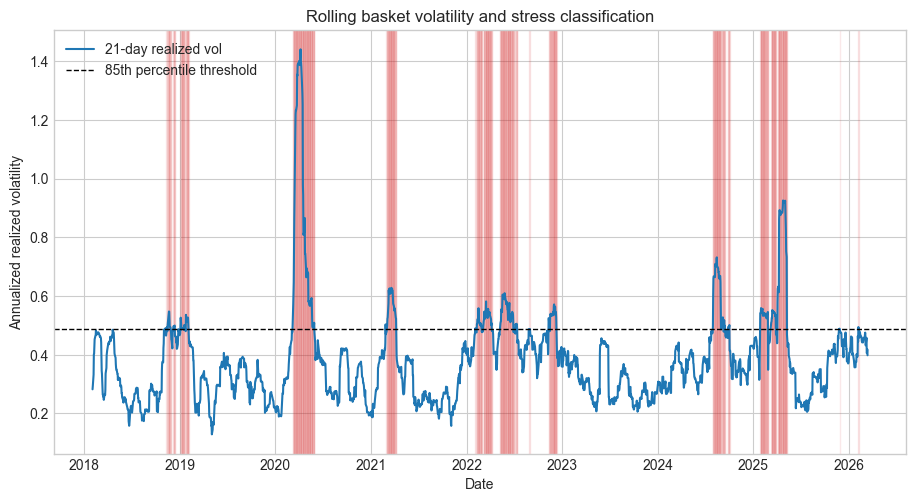

In [9]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(regime_labels.index, regime_labels["rolling_realized_vol"], label="21-day realized vol", linewidth=1.5)
ax.axhline(stress_threshold, color="black", linestyle="--", linewidth=1.0, label=f"{int(stress_quantile * 100)}th percentile threshold")

in_stress = regime_labels["regime"].to_numpy()
dates = regime_labels.index.to_numpy()
for idx in range(len(regime_labels) - 1):
    if in_stress[idx] == 1:
        ax.axvspan(dates[idx], dates[idx + 1], color="tab:red", alpha=0.10)

ax.set_title("Rolling basket volatility and stress classification")
ax.set_ylabel("Annualized realized volatility")
ax.set_xlabel("Date")
ax.legend()
plt.show()

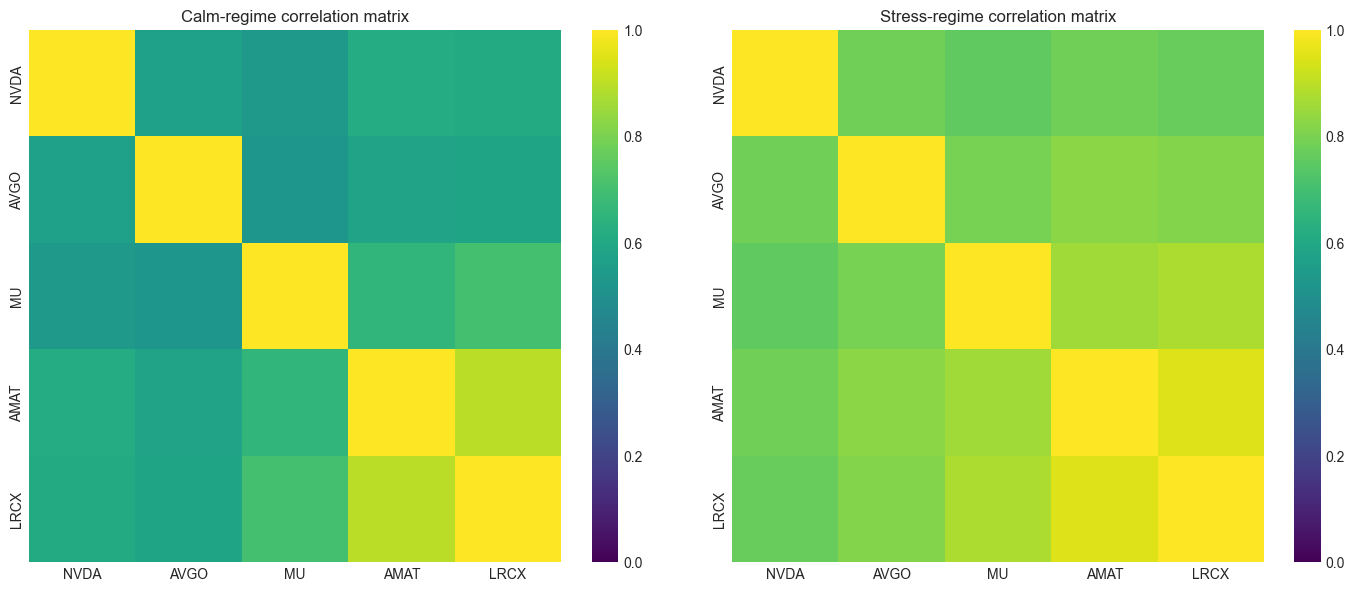

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)
sns.heatmap(calm_corr, cmap="viridis", vmin=0, vmax=1, square=True, ax=axes[0])
axes[0].set_title("Calm-regime correlation matrix")
sns.heatmap(stress_corr, cmap="viridis", vmin=0, vmax=1, square=True, ax=axes[1])
axes[1].set_title("Stress-regime correlation matrix")
plt.show()

In [11]:
eigenvalue_table = pd.DataFrame(
    {
        "matrix": ["constant", "calm", "stress"],
        "min_eigenvalue": [
            float(np.linalg.eigvalsh(constant_corr.to_numpy()).min()),
            float(np.linalg.eigvalsh(calm_corr.to_numpy()).min()),
            float(np.linalg.eigvalsh(stress_corr.to_numpy()).min()),
        ],
    }
)
eigenvalue_table.to_csv(DATA_DIR / "correlation_matrix_eigenvalue_check.csv", index=False)

display(Markdown("## Correlation-matrix PSD check"))
display(eigenvalue_table)

## Correlation-matrix PSD check

,matrix,min_eigenvalue
0,constant,0.0849
1,calm,0.1022
2,stress,0.0522


## What this notebook produced

The real-data folder now contains the first-stage calibration artifacts:

- aligned historical price panel;
- daily log returns;
- annualized volatility estimates;
- constant, calm, and stress correlation matrices;
- empirical regime labels and transition matrix.

The next notebook can use these saved outputs to:

1. regularize the correlation matrices if needed;
2. build a real-data Monte Carlo pricing engine;
3. price hypothetical basket options under constant and regime-switching correlation.